# SCL Dilation Mask

Cloud masking is one of the most common operations in Earth Observation science. Both the Copernicus DataSpace Ecosystem (CDSE) and Terrascope backend instances of openEO provide a non-standard, pre-defined `to_scl_dilation_mask` process. This notebook explains what this process does, how it can be used on the CDSE and Terrascope backends, and - finally - how it can be reproduced on other backend using standard openEO processes. 

### Algorithm

The `to_scl_dilation_mask` process generates a cloud/shadow mask from the Sentinel-2 **Scene Classification Layer (SCL)** band. Rather than using the raw SCL classification directly, it *dilates* cloud and shadow pixels outward using Gaussian convolution, producing a conservative mask that also flags pixels near clouds. For example, pixels affected by cloud shadows, partially cloudy edges, or adjacency effects.

Two independent binary masks are derived from the SCL band and combined with a logical OR:

#### Mask 1 — dilation of non-valid pixels (fine-scale, kernel ≈ 17 px)

1. A binary mask is created where `1` indicates pixels **not** in the "valid" class set (`mask1_values`; by default: dark area = 2, vegetation = 4, bare soil = 5, water = 6, unclassified = 7) and `0` indicates valid pixels.
2. Optionally, the mask is morphologically **eroded** with a circular kernel to remove isolated invalid pixels before dilation. By default this does not happen.
3. The binary mask is convolved with a **Gaussian kernel** (default size 17 px).
4. The result is thresholded at **0.057** → pixels within roughly one kernel radius of any non-valid pixel are masked.

#### Mask 2 — dilation of cloud/shadow pixels (coarse-scale, kernel ≈ 201 px)

1. A binary mask is created where `1` indicates pixels **in** the explicit cloud/shadow class set (`mask2_values`; by default: cloud shadow = 3, medium-probability cloud = 8, high-probability cloud = 9, thin cirrus = 10, snow/ice = 11).
2. Optional morphological **erosion** (same as above).
3. Convolution with a much larger **Gaussian kernel** (default size 201 px), capturing the long-range influence of cloud shadows.
4. Threshold at **0.025** → even faint Gaussian tails from distant cloud pixels contribute to masking.

#### Final mask

$$\text{mask} = \text{mask}_1 \;\lor\; \text{mask}_2$$

A pixel value of `1` means *masked / invalid*; `0` means *valid*. The dual-kernel design ensures that both small residual artefacts (mask 1, fine scale) and large cloud-shadow footprints (mask 2, coarse scale) are captured.

#### SCL class reference

| SCL value | Class |
|-----------|-------|
| 2 | Dark area pixels |
| 3 | Cloud shadows |
| 4 | Vegetation |
| 5 | Bare soils |
| 6 | Water |
| 7 | Unclassified |
| 8 | Cloud (medium probability) |
| 9 | Cloud (high probability) |
| 10 | Thin cirrus |
| 11 | Snow / ice |


### Example on CDSE backend

The `to_scl_dilation_mask` process expects as input a DataCube that only contains the Sentinel-2 SCL layer. The output is a binary mask of the same dimensions as the original cube, which can further be used as a mask in the openEO `mask` process.

First we connect to the CDSE backend and load in the SCL layer of Sentinel-2

In [7]:
import openeo 

c = openeo.connect('openeo.dataspace.copernicus.eu').authenticate_oidc()

scl = c.load_collection(
    "SENTINEL2_L2A",
    spatial_extent={"west": 4.279, "south": 50.218, "east": 4.626, "north": 50.423},
    temporal_extent=["2020-01-01", "2020-01-31"],
    bands=["SCL"]
)

Authenticated using refresh token.


Next, we apply the `to_scl_dilation_mask` process. Since this is a non-standard openEO process, the Python Client does not provide a convenience method for this process. We therefore apply it using the generic process constructor.

In [8]:
cloud_mask = scl.process(
    data=scl,
    process_id="to_scl_dilation_mask"
)

Finally, we execute the process graph on the backend and download the results locally. 

In [9]:
job = cloud_mask.execute_batch(
    title="SCL dilation mask using pre-defined process on CDSE backend",
    out_format="netcdf"
)

results = job.get_results()

results.download_files("./to_scl_dilation_mask_cdse/")

0:00:00 Job 'j-260806142630485db275a316cb9c1106': send 'start'
0:00:04 Job 'j-260806142630485db275a316cb9c1106': created (progress 0%)
0:00:10 Job 'j-260806142630485db275a316cb9c1106': queued (progress 0%)
0:00:16 Job 'j-260806142630485db275a316cb9c1106': queued (progress 0%)
0:00:24 Job 'j-260806142630485db275a316cb9c1106': queued (progress 0%)
0:00:34 Job 'j-260806142630485db275a316cb9c1106': queued (progress 0%)
0:00:46 Job 'j-260806142630485db275a316cb9c1106': running (progress N/A)
0:01:02 Job 'j-260806142630485db275a316cb9c1106': running (progress N/A)
0:01:21 Job 'j-260806142630485db275a316cb9c1106': running (progress N/A)
0:01:45 Job 'j-260806142630485db275a316cb9c1106': running (progress N/A)
0:02:15 Job 'j-260806142630485db275a316cb9c1106': running (progress N/A)
0:02:52 Job 'j-260806142630485db275a316cb9c1106': running (progress N/A)
0:03:39 Job 'j-260806142630485db275a316cb9c1106': running (progress N/A)
0:04:37 Job 'j-260806142630485db275a316cb9c1106': running (progress N/

[PosixPath('to_scl_dilation_mask_cdse/openEO.nc'),
 PosixPath('to_scl_dilation_mask_cdse/job-results.json')]

### Replication using standard openEO processes

The `to_scl_dilation_mask` process is a non-standard openEO process and therefore not available on all backends. In `to_scl_dilation_mask.py` a function called `to_scl_dilation_mask` is constructed - using standard openEO processes - that can be used across all backends. It's mostly based on the openEO `apply_kernel` process. Below a code snippet is shown that illustrates it's usage. 

**Note that this is just for illustration purposes. It is strongly recommended to use the pre-defined `to_scl_dilation_mask` process when working on the CDSE or Terrascope openEO backend.**

In [10]:
import openeo 
from to_scl_dilation_mask import to_scl_dilation_mask

c = openeo.connect('openeo.dataspace.copernicus.eu').authenticate_oidc()

scl = c.load_collection(
    "SENTINEL2_L2A",
    spatial_extent={"west": 4.279, "south": 50.218, "east": 4.626, "north": 50.423},
    temporal_extent=["2020-01-01", "2020-01-31"],
    bands=["SCL"]
)

cloud_mask = to_scl_dilation_mask(scl)

job = cloud_mask.execute_batch(
    title="SCL dilation mask using standard openEO processes",
    out_format="netcdf"
)

job.get_results().download_files("./to_scl_dilation_mask_standard/")

Authenticated using refresh token.
0:00:00 Job 'j-2608061432144c8cb224e83a183b2732': send 'start'
0:00:07 Job 'j-2608061432144c8cb224e83a183b2732': queued (progress 0%)
0:00:13 Job 'j-2608061432144c8cb224e83a183b2732': queued (progress 0%)
0:00:21 Job 'j-2608061432144c8cb224e83a183b2732': queued (progress 0%)
0:00:31 Job 'j-2608061432144c8cb224e83a183b2732': queued (progress 0%)
0:00:42 Job 'j-2608061432144c8cb224e83a183b2732': queued (progress 0%)
0:00:56 Job 'j-2608061432144c8cb224e83a183b2732': queued (progress 0%)
0:01:12 Job 'j-2608061432144c8cb224e83a183b2732': running (progress N/A)
0:01:33 Job 'j-2608061432144c8cb224e83a183b2732': running (progress N/A)
0:01:58 Job 'j-2608061432144c8cb224e83a183b2732': running (progress N/A)
0:02:30 Job 'j-2608061432144c8cb224e83a183b2732': running (progress N/A)
0:03:09 Job 'j-2608061432144c8cb224e83a183b2732': running (progress N/A)
0:03:58 Job 'j-2608061432144c8cb224e83a183b2732': running (progress N/A)
0:04:57 Job 'j-2608061432144c8cb224e83

[PosixPath('to_scl_dilation_mask_standard/openEO.nc'),
 PosixPath('to_scl_dilation_mask_standard/job-results.json')]

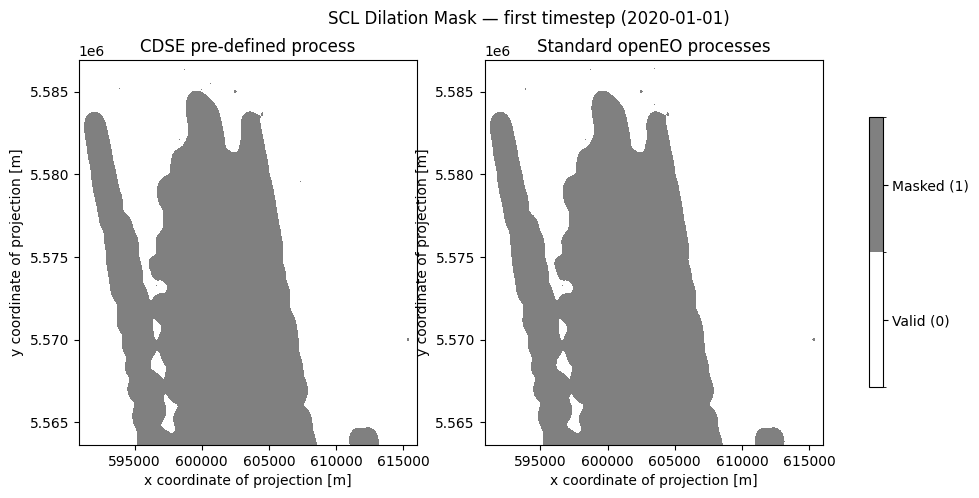

In [13]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

ds_standard = xr.open_dataset("./to_scl_dilation_mask_standard/openEO.nc")
ds_cdse = xr.open_dataset("./to_scl_dilation_mask_cdse/openEO.nc")

scl_variable = "SCL"
timestep = 0

mask_standard = ds_standard[scl_variable].isel(t=timestep)
mask_cdse = ds_cdse[scl_variable].isel(t=timestep)

cmap = mcolors.ListedColormap(["white", "gray"])
bounds = [-0.5, 0.5, 1.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

mask_cdse.plot(ax=axes[0], cmap=cmap, norm=norm, add_colorbar=False)
axes[0].set_title("CDSE pre-defined process")

mask_standard.plot(ax=axes[1], cmap=cmap, norm=norm, add_colorbar=False)
axes[1].set_title("Standard openEO processes")

# Shared colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = fig.colorbar(sm, ax=axes, ticks=[0, 1], shrink=0.7)
cbar.ax.set_yticklabels(["Valid (0)", "Masked (1)"])

plt.suptitle(f"SCL Dilation Mask — first timestep ({str(mask_cdse.t.values)[:10]})")
# plt.tight_layout()
plt.show()
